In [188]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import brentq
import calendar
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose
import requests




In [189]:
MONTH_LABELS = ['Jan','Feb','Mar','Apr','May','Jun',
  'Jul','Aug','Sep','Oct','Nov','Dec']

LATITUDE     = 26.92
LONGITUDE    = 70.90
CAPACITY_KWP = 1000
PANEL_EFF    = 0.20
PANEL_AREA   = 5.0

In [190]:

data= pd.read_csv('hourly.csv')
data.columns = ['year','month','day','hour','GHI','DNI','DHI',
                  'temp','wind','humidity','cloud']
data.head()


,year,month,day,hour,GHI,DNI,DHI,temp,wind,humidity,cloud
0,2013,1,1,0,0.0,0.0,0.0,9.75,1.38,44.97,0.14
1,2013,1,1,1,0.0,0.0,0.0,9.38,1.33,46.10,0.21
2,2013,1,1,2,0.0,0.0,0.0,8.85,1.34,47.91,0.28
3,2013,1,1,3,0.0,0.0,0.0,8.34,1.37,49.59,1.94
4,2013,1,1,4,0.0,0.0,0.0,8.07,1.35,50.52,1.94


In [191]:
data.shape

(96408, 11)

In [192]:
data.replace(-999, np.nan, inplace=True)

In [193]:
data.isnull().sum().sum()

np.int64(0)

In [194]:
df=data.copy()
df['datetime'] = pd.to_datetime(
    df['year'].astype(str)+'-'+df['month'].astype(str).str.zfill(2)+'-'+
    df['day'].astype(str).str.zfill(2)+' '+df['hour'].astype(str).str.zfill(2)+':00:00')
df = df.set_index('datetime').sort_index()
df = df[df['GHI'] > 0].copy()

In [195]:

df.index.min()



Timestamp('2013-01-01 07:00:00')

In [196]:
df.index.max()

Timestamp('2023-12-31 17:00:00')

In [197]:
df['year'].nunique()

11

In [198]:

days_present  = df.resample('D').size()
full_days     = pd.date_range(df.index.min().date(), df.index.max().date(), freq='D')
missing_days  = len(full_days) - len(days_present[days_present>0])
print(f"  Missing days : {missing_days}")
print(f"  Avg hrs/day  : {len(df)/df['year'].nunique()/365:.1f}")



  Missing days : 0
  Avg hrs/day  : 12.5


In [199]:
df.describe()

,year,month,day,hour,GHI,DNI,DHI,temp,wind,humidity,cloud
count,50026.000000,50026.000000,50026.000000,50026.000000,50026.000000,50026.000000,50026.000000,50026.000000,50026.000000,50026.000000,50026.000000
mean,2017.999820,6.501619,15.698737,11.797665,457.388674,409.343960,167.563194,30.750932,3.276167,32.626417,21.361011
std,3.161883,3.321586,8.783132,3.635732,299.264458,281.939792,99.484179,7.845331,1.824205,18.992984,28.960316
min,2013.000000,1.000000,1.000000,5.000000,1.080000,0.000000,1.150000,2.050000,0.010000,2.830000,0.000000
25%,2015.000000,4.000000,8.000000,9.000000,180.400000,143.195000,95.792500,25.590000,1.820000,17.470000,0.800000
50%,2018.000000,6.000000,16.000000,12.000000,467.980000,419.985000,159.790000,31.690000,3.000000,28.460000,6.070000
75%,2021.000000,9.000000,23.000000,15.000000,709.322500,646.560000,230.837500,36.880000,4.440000,43.850000,32.600000
max,2023.000000,12.000000,31.000000,18.000000,1085.220000,1164.920000,593.240000,47.530000,12.120000,100.000000,100.000000


In [200]:

for col in ['GHI','DNI','DHI','temp','wind','humidity','cloud']:
    Q1,Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR   = Q3-Q1
    n_out = len(df[(df[col]<Q1-1.5*IQR)|(df[col]>Q3+1.5*IQR)])
    print(f"  {col:<10} {n_out:>5} outliers ({n_out/len(df)*100:.1f}%)")


  GHI            0 outliers (0.0%)
  DNI            0 outliers (0.0%)
  DHI          386 outliers (0.8%)
  temp         231 outliers (0.5%)
  wind         388 outliers (0.8%)
  humidity     528 outliers (1.1%)
  cloud       3982 outliers (8.0%)


In [201]:

def get_nasa_albedo(lat, lon, start='20010101', end='20231231'):
    url = "https://power.larc.nasa.gov/api/temporal/daily/point"
    params = {
        'parameters' : 'ALLSKY_SRF_ALB',  
        'community'  : 'RE',
        'longitude'  : lon,
        'latitude'   : lat,
        'start'      : start,
        'end'        : end,
        'format'     : 'JSON'
    }
    r = requests.get(url, params=params)
    data = r.json()['properties']['parameter']['ALLSKY_SRF_ALB']
    albedo_series = pd.Series(data)
    albedo_series.index = pd.to_datetime(albedo_series.index, format='%Y%m%d')
    albedo_series.replace(-999, np.nan, inplace=True)
    return albedo_series


albedo_varanasi = get_nasa_albedo(lat=26.92, lon=70.9)
print(f"Mean albedo: {albedo_varanasi.mean():.3f}")
print(f"Monsoon avg: {albedo_varanasi[albedo_varanasi.index.month.isin([6,7,8,9])].mean():.3f}")
print(f"Winter avg : {albedo_varanasi[albedo_varanasi.index.month.isin([12,1,2])].mean():.3f}")

Mean albedo: 0.226
Monsoon avg: 0.214
Winter avg : 0.235



# solar geometry 


In [202]:

df['albedo'] = get_nasa_albedo(lat=26.92, lon=70.9).reindex(df.index).fillna(0.20)
def solar_position(doy, hour, lat_deg, lon_deg):
  # Returns solar_altitude (°), solar_azimuth (°), hour_angle (°).
    lat  = np.radians(lat_deg)
    decl = np.radians(23.45*np.sin(np.radians(360*(284+doy)/365)))
    B    = np.radians(360*(doy-81)/364)
    eot  = 9.87*np.sin(2*B) - 7.53*np.cos(B) - 1.5*np.sin(B)
    lstm = 15*round(lon_deg/15)
    ha   = np.radians(15*(hour + (eot+4*(lon_deg-lstm))/60 - 12))
    cz   = np.clip(np.sin(lat)*np.sin(decl)+np.cos(lat)*np.cos(decl)*np.cos(ha), 0, 1)
    alt  = np.degrees(np.arcsin(cz))
    caz  = ((np.sin(decl)*np.cos(lat)-np.cos(decl)*np.sin(lat)*np.cos(ha))
            /np.clip(np.cos(np.radians(alt)),0.001,1))
    az   = np.degrees(np.arccos(np.clip(caz,-1,1)))
    if ha > 0: az = -az
    return alt, az, np.degrees(ha)


In [203]:
#poa calculation
def poa_irradiance(ghi, dni, dhi, tilt_deg, doy, hour, albedo, panel_azimuth_deg=180,lat_deg=LATITUDE, lon_deg=LONGITUDE):
    t    = np.radians(tilt_deg)
    pa   = np.radians(panel_azimuth_deg)
    lat  = np.radians(lat_deg)
    decl = np.radians(23.45*np.sin(np.radians(360*(284+doy)/365)))
    B    = np.radians(360*(doy-81)/364)
    eot  = 9.87*np.sin(2*B) - 7.53*np.cos(B) - 1.5*np.sin(B)
    lstm = 15*round(lon_deg/15)
    ha   = np.radians(15*(hour + (eot+4*(lon_deg-lstm))/60 - 12))

    cos_aoi = np.clip( np.sin(decl)*np.sin(lat)*np.cos(t)
        - np.sin(decl)*np.cos(lat)*np.sin(t)*np.cos(pa)
        + np.cos(decl)*np.cos(lat)*np.cos(t)*np.cos(ha)
        + np.cos(decl)*np.sin(lat)*np.sin(t)*np.cos(pa)*np.cos(ha)
        + np.cos(decl)*np.sin(t)*np.sin(pa)*np.sin(ha),
        0, 1)#duffie and beckman 

    return (dni*cos_aoi + dhi*(1+np.cos(t))/2 +ghi*albedo*(1-np.cos(t))/2)


In [204]:
#N-S horizontal axis 
def standard_tracker_tilt(solar_zenith_deg, solar_azimuth_deg):
    #(0° = flat, 90° = vertical).
    z  = np.radians(solar_zenith_deg)
    az = np.radians(solar_azimuth_deg)   # 0=N, 90=E, 180=S, 270=W
    tracker_theta = np.degrees(np.arctan2(np.sin(z) * np.sin(az),np.cos(z)))
    # Mechanical rotation limits
    tracker_theta = np.clip(tracker_theta, -60, 60)
    tilt = abs(tracker_theta)
    azimuth = 270 if tracker_theta > 0 else 90

    return tilt, azimuth, tracker_theta


In [205]:
def poa_tracker_standard(ghi, dni, dhi, tracker_theta_deg, solar_zenith_deg, solar_azimuth_deg, albedo):
    z = np.radians(solar_zenith_deg)
    az = np.radians(solar_azimuth_deg)
    th = np.radians(tracker_theta_deg)

    # exact AOI for N-S horizontal rotating tracker
    cos_aoi = ( np.sin(z)*np.sin(az)*np.sin(th) +np.cos(z)*np.cos(th))
    cos_aoi = np.clip(cos_aoi, 0, 1)

    tilt = abs(tracker_theta_deg)
    t = np.radians(tilt)
    # incidence angle modifier + practical tracker loss
    iam = 1 - 0.08*(1-cos_aoi)

    poa = ( dni*cos_aoi*iam*0.95 +     # 5% practical tracking optical loss
            dhi*(1+np.cos(t))/2 +ghi*albedo*(1-np.cos(t))/2)
    return poa

# Brute force- checking all angles one by one


In [206]:
import time
# Start brute-force timer
start_time = time.perf_counter()

if 'solar_altitude' not in df.columns:
    sol_pos = [solar_position(i.dayofyear, i.hour+i.minute/60.0, LATITUDE, LONGITUDE)
               for i in df.index]
    df['solar_altitude'], df['solar_azimuth_true'], df['hour_angle'] = zip(*sol_pos)

THETA_RANGE = np.arange(-60, 61, 5)

opt_thetas, poa_opts = [], []
std_tilts, std_azs, std_thetas = [], [], []
poa_stds, poa_fixeds = [], []

for idx, row in df.iterrows():

    doy  = idx.dayofyear
    hour = idx.hour + idx.minute/60.0
    alb  = row['albedo']
    zen  = 90 - row['solar_altitude']
    az_N = row['solar_azimuth_true']

    # night hours
    if row['GHI'] <= 1 or row['solar_altitude'] <= 0:
        std_tilts.append(0)
        std_azs.append(180)
        poa_stds.append(0)
        std_thetas.append(0)
        poa_fixeds.append(0)
        opt_thetas.append(0)
        poa_opts.append(0)
        continue

    # standard
    st_tilt, st_az,st_theta = standard_tracker_tilt(zen, az_N)
    std_tilts.append(st_tilt)
    std_azs.append(st_az)
    std_thetas.append(st_theta)

    poa_stds.append(poa_tracker_standard(row['GHI'], row['DNI'], row['DHI'], st_tilt, zen, az_N, alb) )

    # fixed
    poa_fixeds.append(poa_irradiance(row['GHI'], row['DNI'], row['DHI'],LATITUDE, doy, hour, alb, 180))
#calculate
    if len(opt_thetas) == 0:
        prev_theta = 0
    else:
        prev_theta = opt_thetas[-1]

    valid_thetas = [th for th in THETA_RANGE if abs(th - prev_theta) <= 10]

    best_p = -1
    best_theta = 0

    for theta in valid_thetas:

        tilt_mag = abs(theta)

        if theta < 0:
            surf_az = 90
        elif theta > 0:
            surf_az = 270
        else:
            surf_az = 180

        p = poa_irradiance(row['GHI'], row['DNI'], row['DHI'], tilt_mag, doy, hour, alb, surf_az)

        if np.isnan(p):
            p = 0

        # actuator movement loss + realistic tracking inefficiency
        p = p * (1 - 0.0008*(abs(theta)**1.35))

        if p > best_p:
            best_p = p
            best_theta = theta

    opt_thetas.append(best_theta)
    poa_opts.append(best_p)

brute_force_time = time.perf_counter() - start_time

df['optimal_theta']    = opt_thetas
df['poa_optimal']      = poa_opts
df['std_tracker_tilt'] = std_tilts
df['std_tracker_az']   = std_azs
df['std_tracker_theta'] = std_thetas
df['poa_std']          = poa_stds
df['poa_fixed']        = poa_fixeds

df['power_optimal'] = df['poa_optimal'] * PANEL_EFF * PANEL_AREA
df['power_fixed']   = df['poa_fixed']   * PANEL_EFF * PANEL_AREA
df['power_std']     = df['poa_std']     * PANEL_EFF * PANEL_AREA

std_gain = (df['power_std'].mean()-df['power_fixed'].mean())/df['power_fixed'].mean()*100
opt_gain = (df['power_optimal'].mean()-df['power_fixed'].mean())/df['power_fixed'].mean()*100

print(f" {'System':<25} {'Avg Power':>12} {'vs Fixed':>10}")
print(f" {'Fixed Tilt':25} {df['power_fixed'].mean():>11.4f} kWh/kWp    —")
print(f" {'Standard Tracker':25} {df['power_std'].mean():>11.4f} kWh/kWp  {std_gain:+.2f}%")
print(f" {'Optimal Brute Force':25} {df['power_optimal'].mean():>11.4f} kWh/kWp  {opt_gain:+.2f}%")
print(f"Brute Force Execution Time : {brute_force_time:.6f} seconds")

 System                       Avg Power   vs Fixed
 Fixed Tilt                   336.8721 kWh/kWp    —
 Standard Tracker             408.8980 kWh/kWp  +21.38%
 Optimal Brute Force          466.6803 kWh/kWp  +38.53%
Brute Force Execution Time : 10.541135 seconds


- Brute force has to do large no of iterations over (-60,60)range
- Thus its very slow
-Here we use ML to make our work faster

# feature engineering

In [207]:

df['month_sin']  = np.sin(2*np.pi*df['month']/12)
df['month_cos']  = np.cos(2*np.pi*df['month']/12)
df['doy_sin']    = np.sin(2*np.pi*df.index.dayofyear/365)
df['doy_cos']    = np.cos(2*np.pi*df.index.dayofyear/365)
df['hour_sin']   = np.sin(2*np.pi*df.index.hour/24)
df['hour_cos']   = np.cos(2*np.pi*df.index.hour/24)

df['dni_ghi_ratio'] = (df['DNI']/df['GHI'].replace(0,np.nan)).fillna(0)

df['season']      = df['month'].map({12:0,1:0,2:0,3:1,4:1,5:1,6:2,7:2,8:2,9:3,10:3,11:3})
df['day_of_year'] = df.index.dayofyear
df['hour_of_day'] = df.index.hour

ML_FEATURES = ['GHI','DNI','DHI','temp','wind','humidity','cloud', 'dni_ghi_ratio','month_sin','month_cos','doy_sin','doy_cos','hour_sin','hour_cos','season','day_of_year','hour_of_day']
TARGET = 'optimal_theta'


# EDA



In [208]:
monthly = df.groupby('month').agg({
    'GHI':'mean','DNI':'mean','DHI':'mean',
    'temp':'mean','humidity':'mean','cloud':'mean','albedo':'mean',
    'dni_ghi_ratio':'mean',
    'optimal_theta':'mean','std_tracker_tilt':'mean',
    'power_optimal':'mean','power_fixed':'mean','power_std':'mean',
}).round(3)
monthly.index = MONTH_LABELS

hourly_agg = df.groupby('hour_of_day').agg({
    'GHI':'mean','DNI':'mean','DHI':'mean',
    'solar_altitude':'mean','optimal_theta':'mean','std_tracker_tilt':'mean',
    'power_optimal':'mean','power_fixed':'mean','power_std':'mean',
}).round(3)
monthly['gain_ml_vs_fixed'] = ((monthly['power_optimal']-monthly['power_fixed'])
                                /monthly['power_fixed']*100).round(2)
monthly['gain_std_vs_fixed'] = ((monthly['power_std']-monthly['power_fixed'])
                                 /monthly['power_fixed']*100).round(2)
monthly['gain_ml_vs_std']   = ((monthly['power_optimal']-monthly['power_std'])
                                /monthly['power_std']*100).round(2)


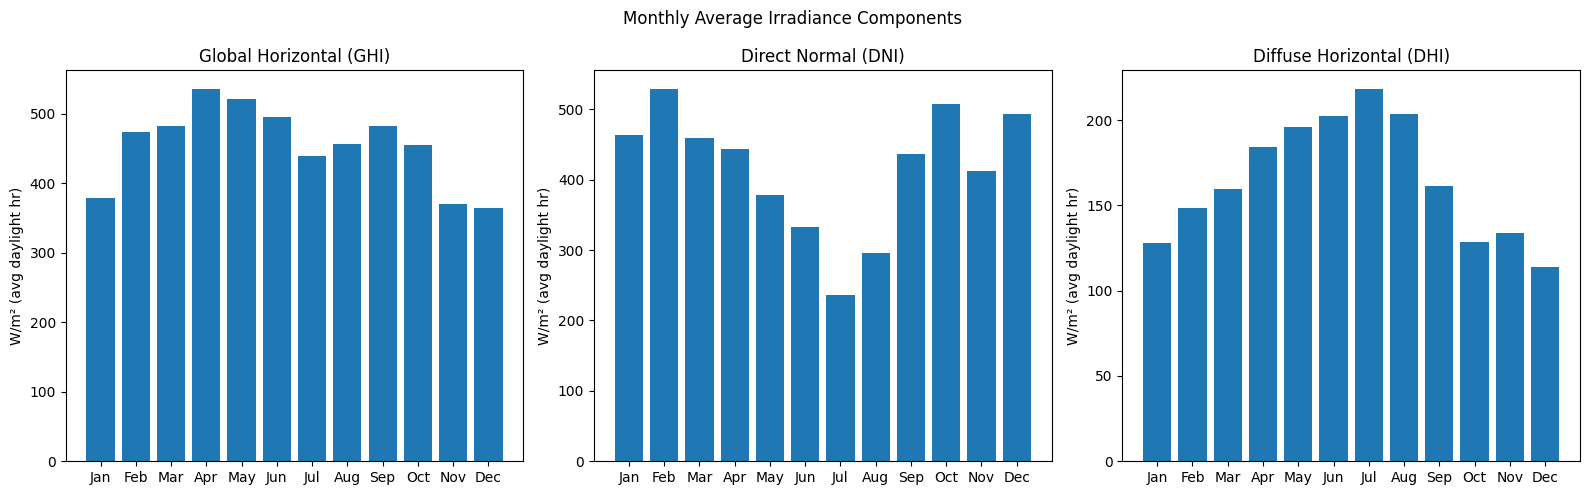

In [209]:

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Monthly Average Irradiance Components ')
x = np.arange(12)
for ax,col,title in zip(axes,
    ['GHI','DNI','DHI'],
    ['Global Horizontal (GHI)','Direct Normal (DNI)','Diffuse Horizontal (DHI)']):
    bars = ax.bar(x, monthly[col])
    ax.set_title(title); ax.set_ylabel('W/m² (avg daylight hr)')
    ax.set_xticks(x); ax.set_xticklabels(MONTH_LABELS)
  
plt.tight_layout(); plt.show()

In [210]:

df['optimal_theta_abs'] = df['optimal_theta'].abs()
df['std_theta_abs']     = df['std_tracker_theta'].abs()

monthly = df.groupby('month').agg({
    'optimal_theta_abs':'mean',
    'std_theta_abs':'mean',
    'power_optimal':'mean',
    'power_fixed':'mean',
    'power_std':'mean',
    'dni_ghi_ratio':'mean',
}).round(3)
monthly.index = MONTH_LABELS

hourly_agg = df.groupby('hour_of_day').agg({
    'optimal_theta':'mean',
    'std_tracker_theta':'mean',
    'solar_altitude':'mean'
}).round(3)


monthly['gain_ml_vs_fixed'] = ((monthly['power_optimal']-monthly['power_fixed'])/monthly['power_fixed']*100).round(2)
monthly['gain_std_vs_fixed'] = ((monthly['power_std']-monthly['power_fixed'])/monthly['power_fixed']*100).round(2)
monthly['gain_ml_vs_std'] = ((monthly['power_optimal']-monthly['power_std'])/monthly['power_std']*100).round(2)



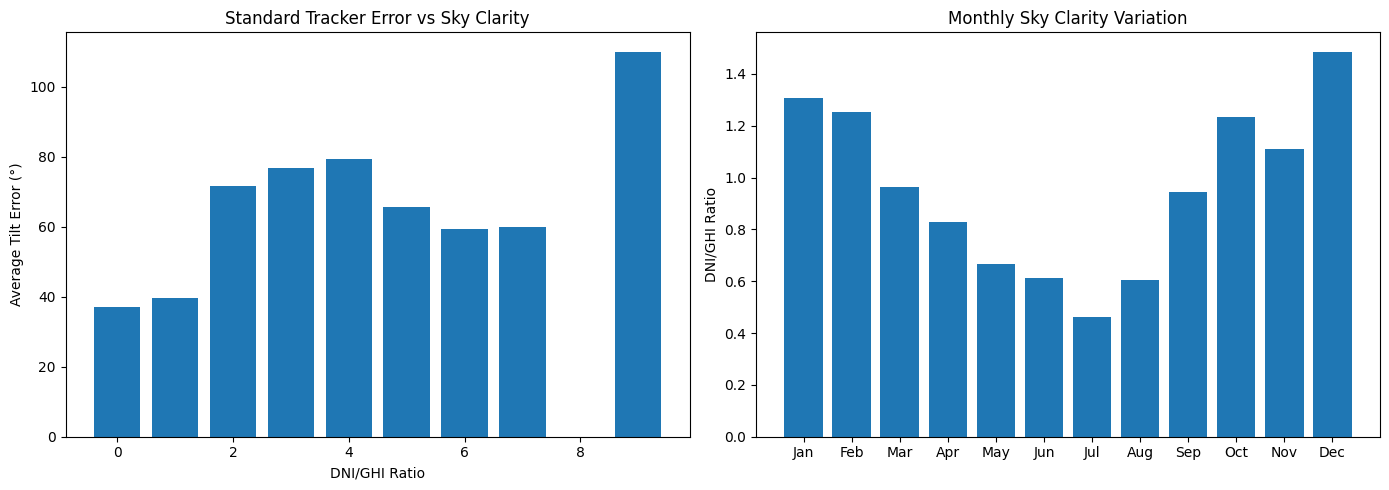

In [211]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tilt error analysis
df['tilt_error_std'] = ( df['optimal_theta'] - df['std_tracker_tilt']).abs()
bins = pd.cut(df['dni_ghi_ratio'], bins=10)
error_by_ratio = (df.groupby(bins, observed=True)['tilt_error_std'].mean())
axes[0].bar( range(len(error_by_ratio)),error_by_ratio.values)
axes[0].set_xlabel('DNI/GHI Ratio')
axes[0].set_ylabel('Average Tilt Error (°)')
axes[0].set_title('Standard Tracker Error vs Sky Clarity')



# Monthly DNI/GHI ratio
bars = axes[1].bar(
    range(12),
    monthly['dni_ghi_ratio']
)
axes[1].set_xticks(range(12))
axes[1].set_xticklabels(MONTH_LABELS)

axes[1].set_ylabel('DNI/GHI Ratio')
axes[1].set_title('Monthly Sky Clarity Variation')


plt.tight_layout()
plt.show()

C:\Users\harsh\AppData\Local\Temp\ipykernel_10296\7332406.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend()


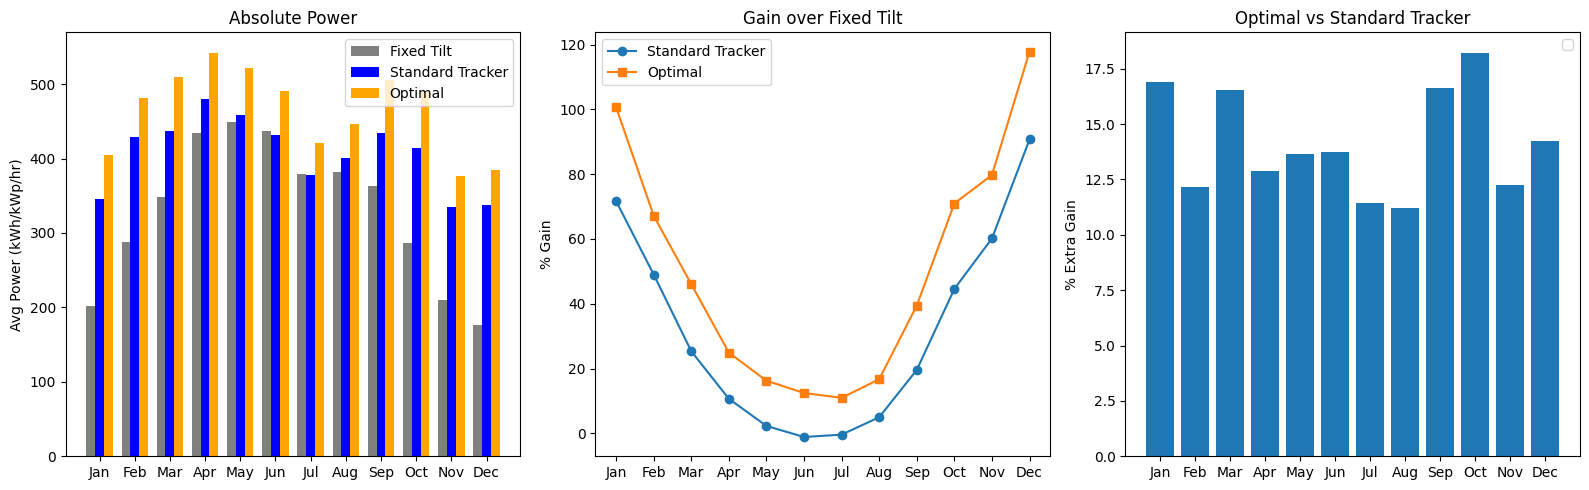

In [212]:
# ── POWER GAIN COMPARISON — ALL THREE SYSTEMS ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
x = np.arange(12)

# Absolute power by month
axes[0].bar(x - 0.25, monthly["power_fixed"],
            width=0.25, color="gray", label="Fixed Tilt")
axes[0].bar(x, monthly["power_std"],
            width=0.25, color="blue", label="Standard Tracker")
axes[0].bar(x + 0.25, monthly["power_optimal"],
            width=0.25, color="orange", label="Optimal")
axes[0].set_xticks(x)
axes[0].set_xticklabels(MONTH_LABELS)
axes[0].set_ylabel("Avg Power (kWh/kWp/hr)")
axes[0].set_title("Absolute Power")
axes[0].legend()
 
# % gain vs fixed
axes[1].plot(
    monthly.index,
    monthly["gain_std_vs_fixed"],
    marker="o",
    label="Standard Tracker"
)
axes[1].plot(
    monthly.index,
    monthly["gain_ml_vs_fixed"],
    marker="s",
    label="Optimal"
)

axes[1].set_ylabel("% Gain")
axes[1].set_title("Gain over Fixed Tilt")
axes[1].legend()

  
# % gain ML vs standard tracker (the key metric)
bars = axes[2].bar( x, monthly["gain_ml_vs_std"])
axes[2].set_xticks(x)
axes[2].set_xticklabels(MONTH_LABELS)
axes[2].set_ylabel("% Extra Gain")
axes[2].set_title("Optimal vs Standard Tracker")
axes[2].legend()
plt.tight_layout(); plt.show()


Here we can clearly see that optimal method gains more power

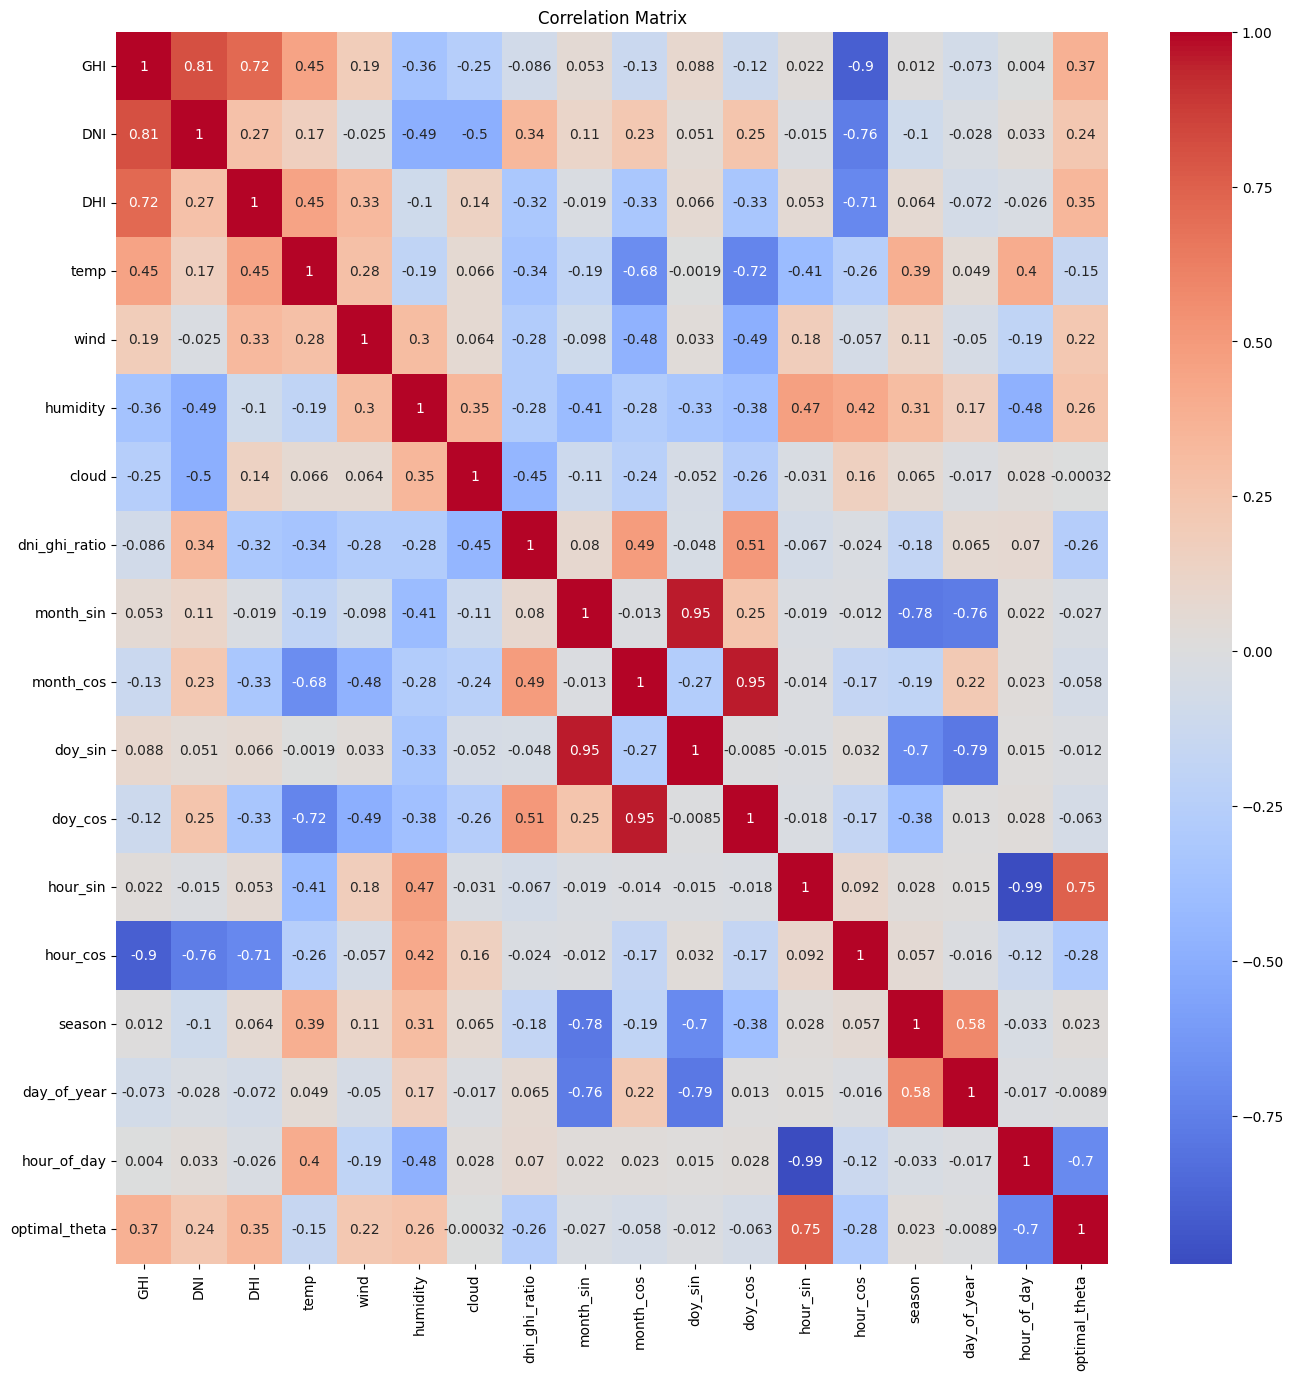

In [213]:
# ── CORRELATION HEATMAP ───────────────────────────────────────────────────────
corr_cols = ML_FEATURES + [TARGET]
corr      = df[corr_cols].corr()
plt.figure(figsize=(16,16))
sns.heatmap(corr, annot=True,cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()



remove multicollinearity

In [214]:
  # Same information as hour_of_day
ML_FEATURES.remove("month_sin")    # Highly correlated with doy_sin
ML_FEATURES.remove("month_cos")    # Highly correlated with doy_cos

In [215]:
ML_FEATURES.remove("hour_sin")    # Highly correlated with hour_of_day
ML_FEATURES.remove("hour_cos")    

In [216]:
ML_FEATURES.remove("doy_sin")    # Highly correlated with day_of_year
ML_FEATURES.remove("doy_cos") 

In [217]:
ML_FEATURES.remove("DNI")    # Highly correlated with ghi

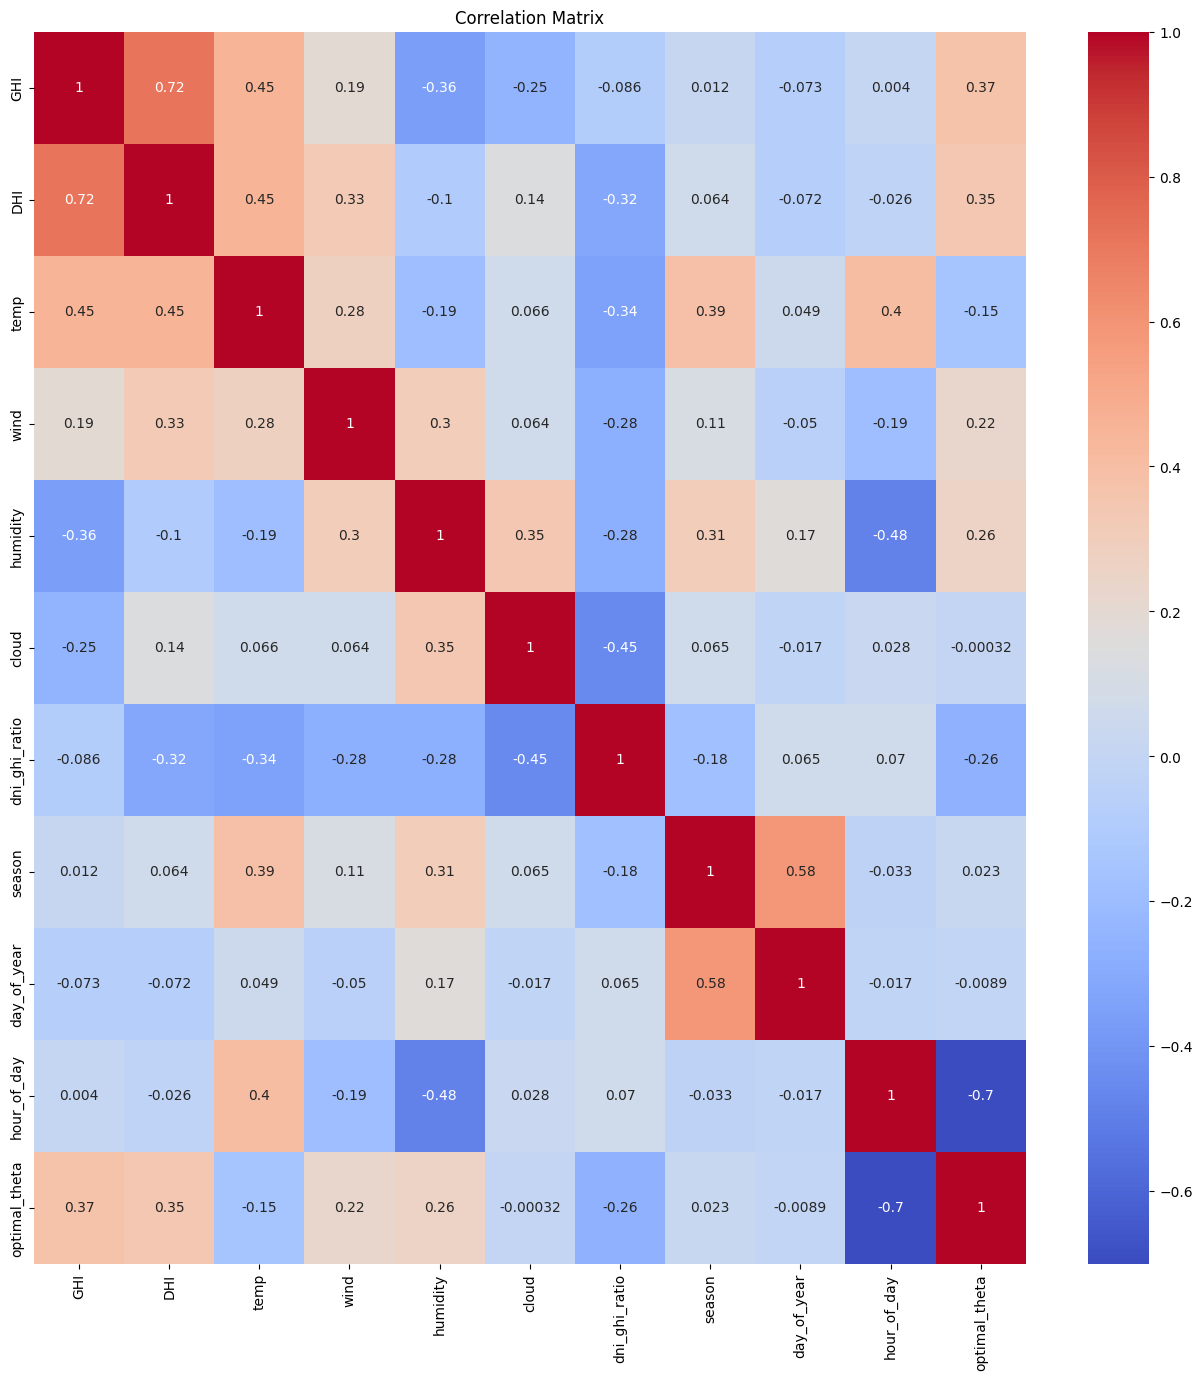

In [218]:
# ── CORRELATION HEATMAP ───────────────────────────────────────────────────────
corr_cols = ML_FEATURES + [TARGET]
corr      = df[corr_cols].corr()
plt.figure(figsize=(16,16))
sns.heatmap(corr, annot=True,cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()



# test train splitting


In [219]:

split_date = '2020-01-01'
train = df[df.index < split_date]
test  = df[df.index >= split_date]

X_train, y_train = train[ML_FEATURES], train[TARGET]
X_test,  y_test  = test[ML_FEATURES],  test[TARGET]



In [220]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((31832, 10), (31832,), (18194, 10), (18194,))

# pipeline


In [221]:
# ── DEFINE MODELS ─────────────────────────────────────────────────────────────
models = {
    'Linear Regression' : Pipeline([('sc',StandardScaler()),
                                     ('m', LinearRegression())]),
    'Decision Tree'     : Pipeline([('sc',StandardScaler()),
                                     ('m', DecisionTreeRegressor(
                                         max_depth=10,random_state=42))]),
    'Random Forest'     : Pipeline([('sc',StandardScaler()),
                                     ('m', RandomForestRegressor(
                                         n_estimators=200,random_state=42,n_jobs=-1))]),
    'Gradient Boosting' : Pipeline([('sc',StandardScaler()),
                                     ('m', GradientBoostingRegressor(
                                         n_estimators=200,learning_rate=0.05,
                                         max_depth=4,random_state=42))]),
  
}
print(f"Models: {list(models.keys())}")

Models: ['Linear Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting']


In [222]:

TARGET = 'optimal_theta'
results = []
for name, pipe in models.items():
    print(f"  Training {name}...", end=' ')
    pipe.fit(X_train, y_train)
    y_pred   = pipe.predict(X_test)
    train_r2 = r2_score(y_train, pipe.predict(X_train))
    r2   = r2_score(y_test, y_pred)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    cv   = cross_val_score(pipe, df[ML_FEATURES], df[TARGET],
                           cv=KFold(n_splits=5,shuffle=False), scoring='r2')
    results.append({'Model':name,'Train R²':round(train_r2,4),
                    'Test R²':round(r2,4),'Gap':round(train_r2-r2,4),
                    'MAE (°)':round(mae,3),'RMSE (°)':round(rmse,3),
                    'CV R²':round(cv.mean(),4),'CV Std':round(cv.std(),4)})
    print(f"R²={r2:.4f}  MAE={mae:.3f}°")

results_df = pd.DataFrame(results).sort_values('Test R²',ascending=False).reset_index(drop=True)

print(results_df.to_string(index=False))


best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
print(f"\n Best: {best_model_name}")
print(f"   R²  = {results_df.iloc[0]['Test R²']}")
print(f"   MAE = {results_df.iloc[0]['MAE (°)']}°")

  Training Linear Regression... R²=0.6843  MAE=8.383°
  Training Decision Tree... R²=0.9315  MAE=2.420°
  Training Random Forest... R²=0.9664  MAE=1.569°
  Training Gradient Boosting... R²=0.9530  MAE=2.577°
            Model  Train R²  Test R²    Gap  MAE (°)  RMSE (°)  CV R²  CV Std
    Random Forest    0.9952   0.9664 0.0289    1.569     3.510 0.9665  0.0020
Gradient Boosting    0.9550   0.9530 0.0020    2.577     4.151 0.9504  0.0035
    Decision Tree    0.9435   0.9315 0.0119    2.420     5.008 0.9316  0.0034
Linear Regression    0.6907   0.6843 0.0065    8.383    10.756 0.6872  0.0112

 Best: Random Forest
   R²  = 0.9664
   MAE = 1.569°


In [223]:
best_est = best_model.named_steps['m']
if hasattr(best_est, 'feature_importances_'):

    imp_df = pd.DataFrame({
        'Feature': ML_FEATURES,
        'Importance': best_est.feature_importances_
    })

    imp_df = imp_df.sort_values(by='Importance', ascending=False)
    print(imp_df.to_string(index=False))

      Feature  Importance
  hour_of_day    0.707699
dni_ghi_ratio    0.088901
          GHI    0.074529
  day_of_year    0.060066
          DHI    0.039426
        cloud    0.010331
         temp    0.006398
       season    0.004308
     humidity    0.004238
         wind    0.004103


#over all gain

In [224]:


df['pred_theta'] = best_model.predict(df[ML_FEATURES]).clip(-60, 60)

poa_ml = []

for i, r in df.iterrows():

    # night hours
    if r['GHI'] <= 1 or r['solar_altitude'] <= 0:
        poa_ml.append(0)
        continue

    theta = r['pred_theta']
    tilt_mag = abs(theta)

    # convert signed theta to surface azimuth
    if theta < 0:
        surf_az = 90      # east-facing
    elif theta > 0:
        surf_az = 270     # west-facing
    else:
        surf_az = 180     # noon / south

    poa = poa_irradiance(
        r['GHI'], r['DNI'], r['DHI'],
        tilt_mag,
        i.dayofyear,
        i.hour + i.minute/60.0,
        r['albedo'],
        surf_az
    )

    if np.isnan(poa):
        poa = 0

    poa_ml.append(poa)

df['poa_ml_pred']   = poa_ml
df['power_ml_pred'] = df['poa_ml_pred'] * PANEL_EFF * PANEL_AREA

# ── Gain metrics ─────────────────────────────────────────────────────────────
std_gain = ((df['power_std'].mean() - df['power_fixed'].mean())
            / df['power_fixed'].mean()) * 100

fixed_gain = ((df['power_ml_pred'].mean() - df['power_fixed'].mean())
                 / df['power_fixed'].mean()) * 100

ml_std_gain = ((df['power_ml_pred'].mean() - df['power_std'].mean())
               / df['power_std'].mean()) * 100


print("  OVERALL GAIN SUMMARY (ENERGY BASIS)")
print(f"  Std Tracker vs Fixed   : {std_gain:+.2f}%")
print(f"  ML vs Fixed            : {fixed_gain:+.2f}%")
print(f"  ML vs Std Tracker      : {ml_std_gain:+.2f}%")

  OVERALL GAIN SUMMARY (ENERGY BASIS)
  Std Tracker vs Fixed   : +21.38%
  ML vs Fixed            : +43.38%
  ML vs Std Tracker      : +18.13%


In [225]:
import time

start = time.perf_counter()

best_model.fit(X_train, y_train)

training_time = time.perf_counter() - start

start = time.perf_counter()
y_pred = best_model.predict(X_test)
prediction_time = time.perf_counter() - start

print(f"Training Time  : {training_time:.4f} seconds")
print(f"Prediction Time: {prediction_time:.6f} seconds")

Training Time  : 2.9577 seconds
Prediction Time: 0.074605 seconds


In [226]:
speedup = brute_force_time / prediction_time
print(f"Brute Force Time : {brute_force_time:.4f} s")
print(f"ML Prediction Time : {prediction_time:.6f} s")
print(f"Speed-up : {speedup:.1f}x")

Brute Force Time : 10.5411 s
ML Prediction Time : 0.074605 s
Speed-up : 141.3x
